# Important information
Seems like there are some changes for modern tensorflow version with the way optimizers minimization works, so instead of book's way of training model, a more straightforward approach is used

In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.keras import backend as backend
import keras
import keras.layers as L
import random
from tqdm import tqdm # not listed in book but useful

c:\Users\yaggod\Desktop\folder\учеба\ReinforcementLearning\.venv2\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


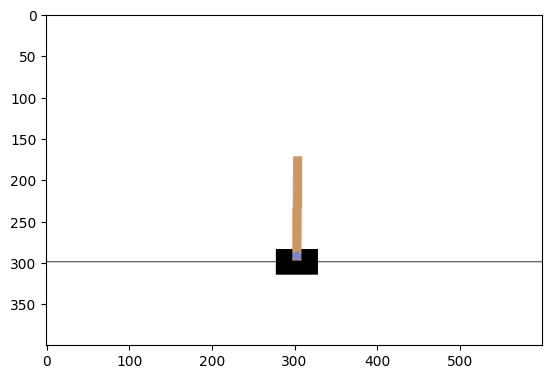

In [2]:
env = gym.make("CartPole-v0", render_mode='rgb_array').env
env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape

plt.imshow(env.render())
plt.show()

In [3]:
# not the same as in the book since book's variant is deprecated
assert len(tf.config.list_physical_devices('GPU')) == 0 

In [4]:
network = keras.models.Sequential()
network.add(L.InputLayer(state_dim))
network.add(L.Dense(100, activation='relu'))
network.add(L.Dense(100, activation='relu'))
network.add(L.Dense(100, activation='relu'))
network.add(L.Dense(int(n_actions), activation='linear'))
network.compile(optimizer='adam')
network.optimizer.learning_rate = 1e-4


assert network.output_shape == (None, n_actions)
assert network.layers[-1].activation == keras.activations.linear

In [5]:
def get_action(state, epsilon=0):
    if random.random() < epsilon:
        return random.randint(0, n_actions - 1)
    q_vals = network.predict(np.array([state]), verbose=0)[0]
    return int(tf.argmax(q_vals))
    

In [6]:
s = env.reset()[0]
assert np.shape(get_action(s)) == ()

In [ ]:
gamma = 0.99

def train_step(model : keras.models.Model , state, next_state, action, reward, done):
    state = np.array([state])
    next_state = np.array([next_state])
    
    with tf.GradientTape() as tape:
        predicted_qvalues = model(state) 
        qvalues_for_actions = tf.reduce_sum(predicted_qvalues * tf.one_hot([action], n_actions), axis=1)

        predicted_next_qvalues = model(next_state)
        predicted_qvalues_for_actions = tf.reduce_max(predicted_next_qvalues, axis=1)

        if(done):
            target = tf.constant([reward])
        else:
            target = reward + gamma * predicted_qvalues_for_actions

        loss = keras.losses.mean_squared_error(qvalues_for_actions, tf.stop_gradient(target))
        gradient = tape.gradient(loss, model.trainable_variables)
        model.optimizer.apply_gradients(zip(gradient, model.trainable_variables))


    

In [8]:
def generate_session(env, t_max = 1000, epsilon = 0, train = False):
    total_reward = 0
    s = env.reset()[0]
    for t in range(t_max):
        a = get_action(s, epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        if train:
            train_step(network, s, next_s, a, r, done)
        
        total_reward += r
        s = next_s
        if done:
            break

    return total_reward

epsilon = 0.5
for i in range(1000):
    session_rewards = [generate_session(env, 500, epsilon, True) for _ in tqdm(range(50), f'Training epoch #{i}\tepsilon = {epsilon:.3f}\t')]   # tqdm is used to track progress
    print(f'\tMean reward = {np.mean(session_rewards):.3f}')
    
    epsilon *= 0.99
    if(epsilon < 1e-4):
        epsilon = 0.1

    if np.mean(session_rewards) > 300:
        print("You won!")
        break

Training epoch #0	epsilon = 0.500	: 100%|██████████| 50/50 [00:44<00:00,  1.13it/s]


	Mean reward = 12.740


Training epoch #1	epsilon = 0.495	: 100%|██████████| 50/50 [00:50<00:00,  1.01s/it]


	Mean reward = 13.140


Training epoch #2	epsilon = 0.490	: 100%|██████████| 50/50 [00:48<00:00,  1.03it/s]


...

	Mean reward = 264.200


Training epoch #32	epsilon = 0.362	: 100%|██████████| 50/50 [11:57<00:00, 14.35s/it]


	Mean reward = 256.140


Training epoch #33	epsilon = 0.359	: 100%|██████████| 50/50 [16:03<00:00, 19.28s/it]

	Mean reward = 322.000
You won!
